In [212]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
plt.style.use('ggplot')

In [213]:
path = '../data/dataset/dataset.csv'
# path = '../data/processed_data/daily_average_all.csv'
data = pd.read_csv(path)
data.head()

,date,pm,location,temp,dew_point,humidity,pressure,wind_speed,precipitation,wind_dir_sin,wind_dir_cos,month,month_sin,month_cos
0,2023-01-01,104.875000,DN,23.5,16.9,68,1015.4,7.1,0.0,0.017452,0.999848,1,0.5,0.866025
1,2023-01-01,79.625000,BN,23.7,16.1,65,1015.3,6.7,0.0,0.707107,0.707107,1,0.5,0.866025
2,2023-01-01,79.375000,KPS,22.9,16.1,68,1015.6,7.2,0.0,0.325568,0.945519,1,0.5,0.866025
3,2023-01-02,90.583333,DN,24.0,17.4,69,1015.7,6.4,0.0,0.156434,0.987688,1,0.5,0.866025
4,2023-01-02,89.500000,BN,24.2,17.9,69,1015.6,5.3,0.0,0.642788,0.766044,1,0.5,0.866025


In [214]:
# data['date'] = pd.to_datetime(data['date'])
# data['month'] = data['date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'hot'
    elif month in [9, 10, 11]:
        return 'rain'
    elif month in [12, 1, 2]:
        return 'winter'

data['season'] = data['month'].apply(get_season)

data_encoded = pd.get_dummies(data, columns=['location', 'season'], drop_first=False)
data_encoded['original_location'] = data['location']
data_encoded = data_encoded.sort_values(by=['original_location', 'date']).reset_index(drop=True)
# data_encoded = data_encoded.drop(columns=['Unnamed: 0','index'])

data_encoded.head()

,date,pm,temp,dew_point,humidity,pressure,wind_speed,precipitation,wind_dir_sin,wind_dir_cos,month,month_sin,month_cos,location_BN,location_DN,location_KPS,season_hot,season_rain,season_winter,original_location
0,2023-01-01,79.625000,23.7,16.1,65,1015.3,6.7,0.0,0.707107,0.707107,1,0.5,0.866025,True,False,False,False,False,True,BN
1,2023-01-02,89.500000,24.2,17.9,69,1015.6,5.3,0.0,0.642788,0.766044,1,0.5,0.866025,True,False,False,False,False,True,BN
2,2023-01-03,110.500000,25.6,18.9,68,1014.7,6.1,0.0,0.515038,0.857167,1,0.5,0.866025,True,False,False,False,False,True,BN
3,2023-01-04,97.166667,26.5,19.1,65,1014.1,5.9,0.0,0.707107,0.707107,1,0.5,0.866025,True,False,False,False,False,True,BN
4,2023-01-05,95.583333,26.1,19.0,66,1013.7,6.3,0.0,0.681998,0.731354,1,0.5,0.866025,True,False,False,False,False,True,BN


In [ ]:
window_size = 7
df_model = data_encoded.copy()

# 1. กำหนดคอลัมน์ที่ไม่ต้องการใช้เป็น Feature (ตามที่คุณ drop ไว้ในโค้ดเดิม)
cols_to_drop = ["date", "month", "original_location","humidity","precipitation","wind_speed"] 

# ฟีเจอร์ที่ต้องการทำข้อมูลย้อนหลัง (Lag)
features_to_lag = [c for c in df_model.columns if c not in cols_to_drop]

# 2. สร้าง Lag Features ด้วย pandas.shift() โดยต้อง Group by สถานที่ก่อนเพื่อไม่ให้ข้อมูลข้ามพื้นที่กัน
for col in features_to_lag:
    for i in range(1, window_size + 1):
        df_model[f'{col}_lag_{i}'] = df_model.groupby('original_location')[col].shift(i)

# 3. Drop แถวที่มี NaN (7 วันแรกของแต่ละสถานที่จะหายไป เพราะไม่มีข้อมูลย้อนหลังให้ดึง)
df_model = df_model.dropna().reset_index(drop=True)

# 4. แบ่ง Train / Val / Test
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

# ดึงเฉพาะคอลัมน์ที่เป็น Lag มาเป็น Features (X)
# (หากต้องการใช้ข้อมูลฤดูกาลของ 'วันปัจจุบัน' ด้วย สามารถเพิ่มชื่อคอลัมน์ต่อท้าย list นี้ได้เลย)
feature_cols = [c for c in df_model.columns if '_lag_' in c]

for loc in df_model['original_location'].unique():
    # เลือกข้อมูลของแต่ละที่และเรียงตามวันที่เพื่อความชัวร์
    df_loc = df_model[df_model['original_location'] == loc].sort_values('date')
    
    X_loc = df_loc[feature_cols].values
    y_loc = df_loc['pm'].values
    
    n = len(X_loc)
    train_end = int(n * 0.8)
    val_end   = int(n * 0.9)
    
    X_train_list.append(X_loc[:train_end])
    y_train_list.append(y_loc[:train_end])
    
    X_val_list.append(X_loc[train_end:val_end])
    y_val_list.append(y_loc[train_end:val_end])
    
    X_test_list.append(X_loc[val_end:])
    y_test_list.append(y_loc[val_end:])

X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)

X_val = np.vstack(X_val_list)
y_val = np.concatenate(y_val_list)

X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

C:\Users\kkako\AppData\Local\Temp\ipykernel_7112\1508101990.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{col}_lag_{i}'] = df_model.groupby('original_location')[col].shift(i)
C:\Users\kkako\AppData\Local\Temp\ipykernel_7112\1508101990.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{col}_lag_{i}'] = df_model.groupby('original_location')[col].shift(i)
C:\Users\kkako\AppData\Local\Temp\ipykernel_7112\1508101990.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

Train shape: (2580, 294) (2580,)
Val shape: (321, 294) (321,)
Test shape: (324, 294) (324,)


In [216]:
def objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical(
        "max_features", ["sqrt", "log2", None]
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse


In [217]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-17 08:07:54,297] A new study created in memory with name: no-name-e6491898-a8f6-4560-aa21-85cef7f4473d
[I 2026-02-17 08:07:54,619] Trial 0 finished with value: 12.347911162010652 and parameters: {'n_estimators': 127, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 12.347911162010652.
[I 2026-02-17 08:07:55,322] Trial 1 finished with value: 12.90509415173575 and parameters: {'n_estimators': 343, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 12.347911162010652.
[I 2026-02-17 08:08:02,667] Trial 2 finished with value: 10.338136764528983 and parameters: {'n_estimators': 332, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 2 with value: 10.338136764528983.
[I 2026-02-17 08:08:03,627] Trial 3 finished with value: 12.30943621452818 and parameters: {'n_estimators': 489, 'max_depth': 9, 'min_sam

Best RMSE: 10.133369777630147
Best params: {'n_estimators': 157, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None}


In [218]:
X_trainval = np.vstack((X_train, X_val))
y_trainval = np.concatenate((y_train, y_val))

best_params = study.best_params

best_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_trainval, y_trainval)

RandomForestRegressor(max_depth=15, max_features=None, min_samples_leaf=5,
                      min_samples_split=3, n_estimators=157, n_jobs=-1,
                      random_state=42)

In [219]:
def mean_bias_error(y_true, y_pred):
    return np.mean(y_pred - y_true)

In [220]:
y_pred = best_rf.predict(X_test)


In [221]:
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mbe  = mean_bias_error(y_test, y_pred)

print("===== Test Metrics =====")
print(f"R2   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MBE  : {mbe:.4f}")


===== Test Metrics =====
R2   : 0.5004
MSE  : 169.2325
MAE  : 10.1872
RMSE : 13.0089
MBE  : 3.2768


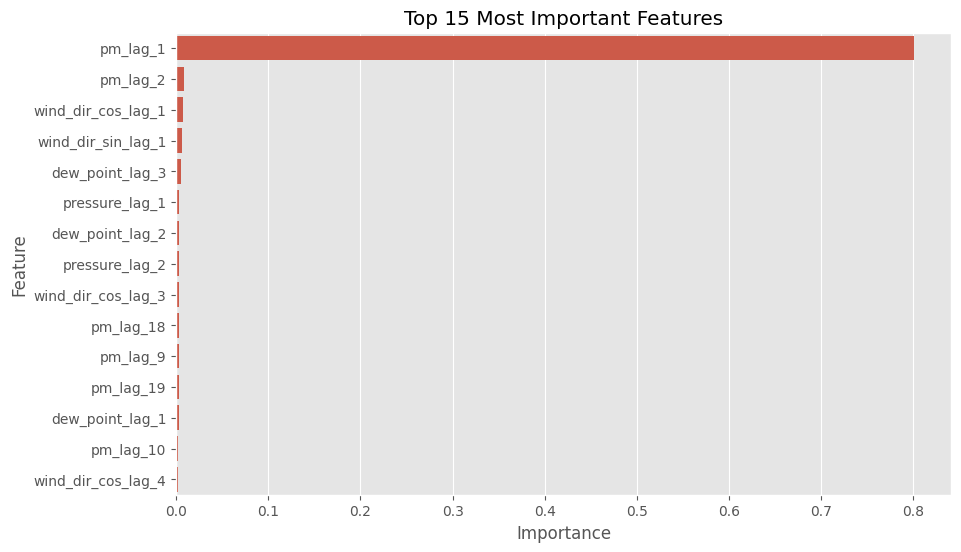

In [222]:
# พล็อตดูว่าข้อมูลย้อนหลังตัวไหนสำคัญที่สุด
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Features')
plt.show()